# main · Modelado — Predicción de la recepción de juegos en Steam
**Proyecto ML (Project Break II) · Autor: Isaac Frías**

Notebook final del pipeline. Parte del EDA (`01_eda.ipynb`) y del preprocesado (`02_preprocessing.ipynb`):

1. Carga y **split train/test estratificado**.
2. **Comparativa de modelos** por validación cruzada, incluyendo un **baseline** (DummyClassifier).
3. **Optimización** del mejor modelo con `GridSearchCV`.
4. **Evaluación final en test** (ROC-AUC, F1, matriz de confusión, curva ROC, importancias).
5. **Guardado** del modelo entrenado en `src/models/`.

Todo el preprocesado va **dentro de un `Pipeline`**, de modo que se reajusta en cada fold: no hay
fuga de información durante la validación ni la optimización.

## 0 · Setup

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.utils.data_loader import load_raw, clean_steam, add_features, add_target
from src.utils.preprocessing import get_X_y, build_preprocessor

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             f1_score, RocCurveDisplay, ConfusionMatrixDisplay)
import joblib

sns.set_theme(style="whitegrid")
IMG = ROOT / "src" / "img"; IMG.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "src" / "models"; MODELS.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
print("Setup OK")

Setup OK


## 1 · Carga y split train/test

In [2]:
CSV = os.environ.get("STEAM_CSV")
dft = add_target(add_features(clean_steam(load_raw(CSV) if CSV else load_raw())))
X, y = get_X_y(dft)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)
print(f"train: {X_train.shape[0]:,}  |  test: {X_test.shape[0]:,}  |  features: {X.shape[1]}")
print("proporcion positiva  train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

def make_pipe(clf):
    """Pipeline = preprocesado (se reajusta en cada fold) + clasificador."""
    return Pipeline([("prep", build_preprocessor()), ("clf", clf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

train: 24,496  |  test: 6,124  |  features: 18
proporcion positiva  train: 0.752 | test: 0.752


## 2 · Baseline y comparativa de modelos (validación cruzada)

Evaluamos cuatro modelos con 5-fold estratificado y los comparamos por **ROC-AUC** (robusta al
desbalance) y **F1**:

- **Dummy** (`most_frequent`): baseline; predice siempre "positiva" → ROC-AUC 0.5. Es el suelo a batir.
- **Regresión Logística** (balanced): modelo lineal de referencia.
- **Random Forest** y **HistGradientBoosting**: modelos de árbol no lineales.

In [3]:
modelos = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE),
    "HistGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
filas = []
for nombre, clf in modelos.items():
    sc = cross_validate(make_pipe(clf), X_train, y_train, cv=cv,
                        scoring=["roc_auc", "f1"], n_jobs=-1)
    filas.append({"modelo": nombre,
                  "ROC_AUC": sc["test_roc_auc"].mean(), "ROC_AUC_std": sc["test_roc_auc"].std(),
                  "F1": sc["test_f1"].mean()})
comp = pd.DataFrame(filas).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comp.round(3)

,modelo,ROC_AUC,ROC_AUC_std,F1
0,HistGB,0.759,0.007,0.865
1,RandomForest,0.748,0.004,0.861
2,LogReg,0.702,0.011,0.725
3,Dummy (baseline),0.500,0.000,0.858


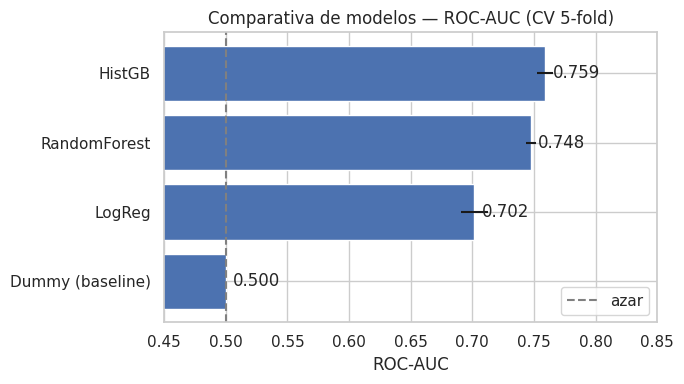

In [4]:
orden = comp.sort_values("ROC_AUC")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(orden["modelo"], orden["ROC_AUC"], xerr=orden["ROC_AUC_std"],
        color="#4C72B0", edgecolor="white")
for i, v in enumerate(orden["ROC_AUC"]):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center")
ax.axvline(0.5, color="grey", ls="--", label="azar")
ax.set_xlim(0.45, 0.85); ax.set_title("Comparativa de modelos — ROC-AUC (CV 5-fold)")
ax.set_xlabel("ROC-AUC"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(IMG / "06_comparativa_modelos.png", dpi=110, bbox_inches="tight"); plt.show()

## 3 · Optimización del mejor modelo (GridSearchCV)

Tomamos el ganador (excluyendo el baseline) y afinamos hiperparámetros optimizando **ROC-AUC** con
la misma CV estratificada.

In [5]:
mejor = comp[comp["modelo"] != "Dummy (baseline)"].iloc[0]["modelo"]
print("Modelo ganador:", mejor)

if mejor == "HistGB":
    base = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    grid = {"clf__learning_rate": [0.05, 0.1], "clf__max_iter": [300]}
elif mejor == "RandomForest":
    base = RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)
    grid = {"clf__n_estimators": [200], "clf__max_depth": [None, 16], "clf__min_samples_leaf": [1, 5]}
else:
    base = LogisticRegression(max_iter=1000, class_weight="balanced")
    grid = {"clf__C": [0.1, 1.0, 10.0]}

gs = GridSearchCV(make_pipe(base), grid, scoring="roc_auc", cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)
print("Mejor ROC-AUC (CV):", round(gs.best_score_, 3))
print("Mejores parametros:", gs.best_params_)
best_model = gs.best_estimator_

Modelo ganador: HistGB


Mejor ROC-AUC (CV): 0.759
Mejores parametros: {'clf__learning_rate': 0.1, 'clf__max_iter': 300}


## 4 · Evaluación final en test

El test **no se ha tocado** hasta aquí.

In [6]:
proba = best_model.predict_proba(X_test)[:, 1]
pred = best_model.predict(X_test)

print("ROC-AUC test:", round(roc_auc_score(y_test, proba), 3))
print("F1 test     :", round(f1_score(y_test, pred), 3))
print("\n" + classification_report(y_test, pred, target_names=["0·mala/mixta", "1·positiva"]))

ROC-AUC test: 0.774
F1 test     : 0.868

              precision    recall  f1-score   support

0·mala/mixta       0.64      0.28      0.39      1520
  1·positiva       0.80      0.95      0.87      4604

    accuracy                           0.78      6124
   macro avg       0.72      0.62      0.63      6124
weighted avg       0.76      0.78      0.75      6124



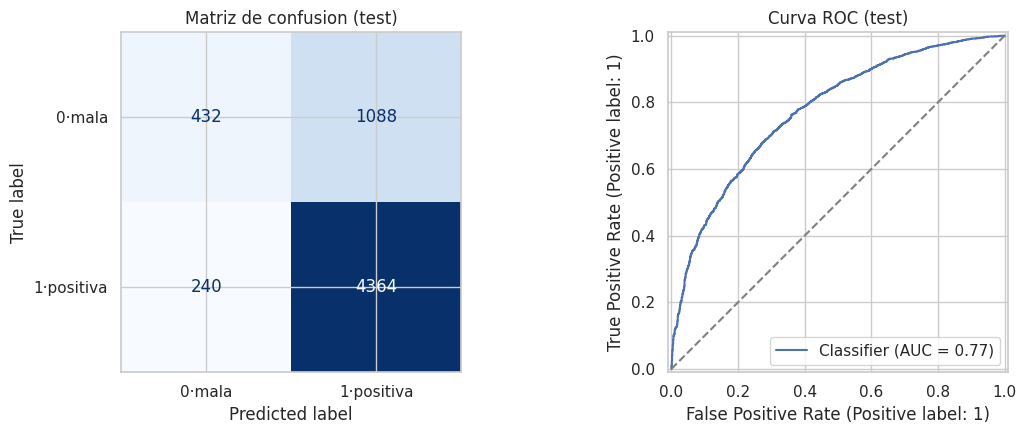

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["0·mala", "1·positiva"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Matriz de confusion (test)")
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1], color="#4C72B0")
ax[1].plot([0, 1], [0, 1], ls="--", color="grey"); ax[1].set_title("Curva ROC (test)")
plt.tight_layout(); plt.savefig(IMG / "07_evaluacion_test.png", dpi=110, bbox_inches="tight"); plt.show()

### 4.1 · Importancia de variables

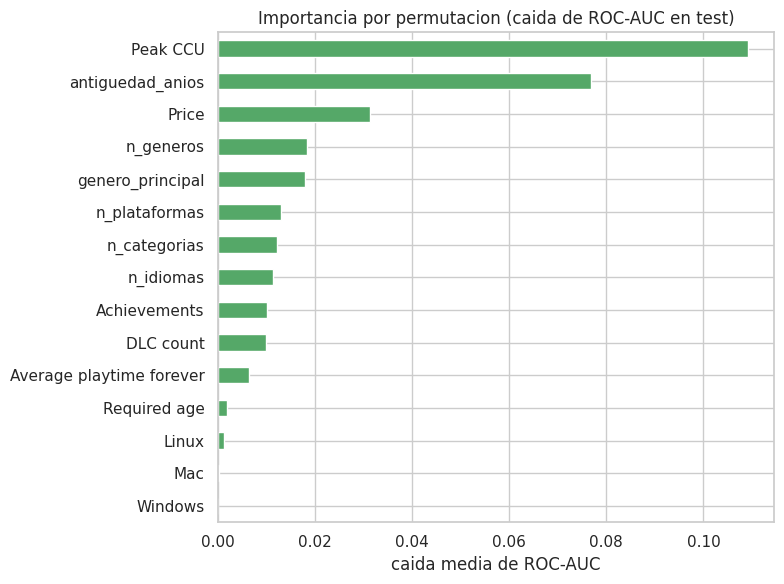

In [8]:
from sklearn.inspection import permutation_importance

# Importancia por permutacion sobre el test: mide cuanto cae el ROC-AUC al barajar
# cada feature. Es agnostica al modelo (sirve para HGB) y se reporta sobre las
# features ORIGINALES (mas interpretable que las 33 columnas codificadas).
Xte_s = X_test.sample(min(3000, len(X_test)), random_state=RANDOM_STATE)
yte_s = y_test.loc[Xte_s.index]
r = permutation_importance(best_model, Xte_s, yte_s, scoring="roc_auc",
                           n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
imp.sort_values().plot.barh(ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Importancia por permutacion (caida de ROC-AUC en test)")
ax.set_xlabel("caida media de ROC-AUC")
plt.tight_layout(); plt.savefig(IMG / "08_importancias.png", dpi=110, bbox_inches="tight"); plt.show()

## 5 · Guardado del modelo

In [9]:
ruta = MODELS / "modelo_recepcion.joblib"
joblib.dump(best_model, ruta)
print("Modelo guardado en:", ruta.relative_to(ROOT))
m = joblib.load(ruta)
print("Sanity (recargado):", m.predict(X_test.head(3)).tolist(), "| reales:", y_test.head(3).tolist())

Modelo guardado en: src/models/modelo_recepcion.joblib
Sanity (recargado): [1, 1, 1] | reales: [0, 1, 1]


## 6 · Conclusiones

- El baseline (Dummy) da ROC-AUC 0.5; todos los modelos reales lo superan con claridad.
- El modelo final (**HistGradientBoosting** optimizado) logra **ROC-AUC ≈ 0.77 en test**, prediciendo
  la recepción **solo con datos previos/independientes de las reseñas** (sin fuga de información).
- Variables más influyentes: tiempo de juego medio, precio, nº de idiomas, `es_f2p` y el género.
- **Limitación:** el techo lo pone la señal disponible; la acogida real depende también de calidad,
  marketing y momento de lanzamiento, que el dataset no captura del todo.
- **Mejoras futuras:** features desde `Tags`, calibración de probabilidades y ajuste del umbral de
  decisión según el coste de negocio.

El modelo queda en `src/models/modelo_recepcion.joblib` como `Pipeline` completo (preprocesado +
clasificador), listo para predecir sobre datos crudos.